In [19]:
import pandas as pd
import numpy as np


# 1. Load the CSV file
df = pd.read_csv('NORS_20251104.csv')

print(df.info())

# 1. Clean the string column by removing commas
df['Illnesses'] = df['Illnesses'].astype(str).str.replace(',', '', regex=False)

# 2. Convert to numeric (float), coercing any remaining non-numeric values to NaN
# 'errors='coerce' is crucial for handling mixed types and non-numeric strings
df['Illnesses'] = pd.to_numeric(df['Illnesses'], errors='coerce')
df['Illnesses'] = df['Illnesses'].astype('int64')
# Get the actual list of illnesses states
unique_illnesses_list = df['Illnesses'].unique()

# The list of columns you want to modify
features_to_fill = ['Illnesses', 'Hospitalizations', 'Deaths']

# Replace NaNs with 0 only in the specified columns
df[features_to_fill] = df[features_to_fill].fillna(0)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66713 entries, 0 to 66712
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          66713 non-null  int64  
 1   Month                         66713 non-null  int64  
 2   State                         66713 non-null  object 
 3   Primary Mode                  66713 non-null  object 
 4   Etiology                      50375 non-null  object 
 5   Serotype or Genotype          16470 non-null  object 
 6   Etiology Status               50375 non-null  object 
 7   Setting                       60804 non-null  object 
 8   Illnesses                     66713 non-null  object 
 9   Hospitalizations              58155 non-null  float64
 10  Info On Hospitalizations      58480 non-null  object 
 11  Deaths                        58785 non-null  float64
 12  Info On Deaths                58463 non-null  object 
 13  F

C:\Users\jared\AppData\Local\Temp\ipykernel_87360\557960963.py:6: DtypeWarning: Columns (8,10,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('NORS_20251104.csv')


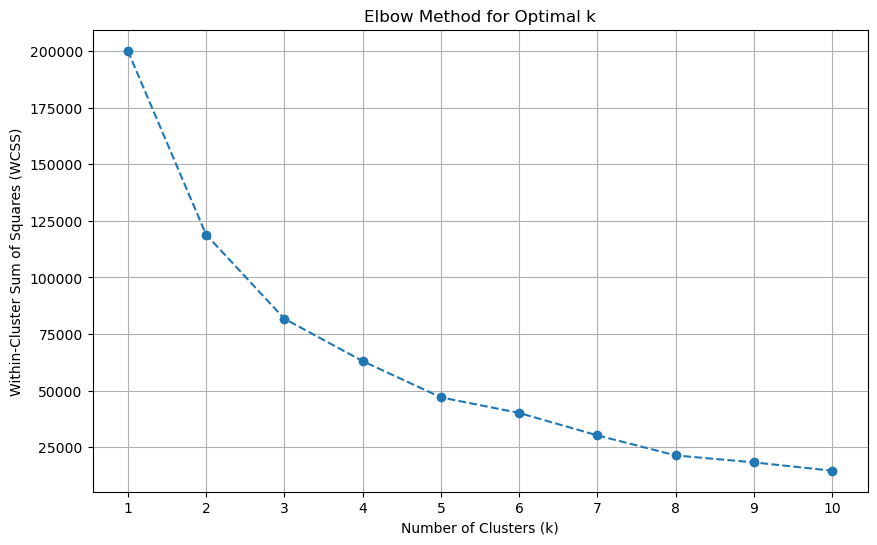

WCSS values for k=1 to 10:
1     200139.000000
2     118934.410348
3      81762.841352
4      63033.948530
5      47013.481884
6      40103.372921
7      30206.960036
8      21351.965586
9      18277.707891
10     14597.918271
dtype: float64


In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Your specified features
features = ['Illnesses', 'Hospitalizations', 'Deaths']
X = df[features] # Assumes your DataFrame df is already loaded

# 1. Z-transformation (Standard Scaling)
# Standard Scaler performs the Z-transformation: (x - mean) / standard deviation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Replace the StandardScaler block with this:
robust_scaler = RobustScaler()
X_scaled_robust = robust_scaler.fit_transform(X)

# Rerun your K-Means models using X_scaled_robust

# 2. Elbow Method with WCSS (Inertia)
wcss = []
k_range = range(1, 11)
random_seed = 511 # Set seed for reproducibility, as requested

for i in k_range:
    # Initialize K-Means with the specified seed and k value
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=random_seed, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # .inertia_ is the WCSS

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(k_range)
plt.show()

# Optional: Print WCSS values to help with elbow determination
print("WCSS values for k=1 to 10:")
print(pd.Series(wcss, index=k_range))

In [21]:
from sklearn.cluster import KMeans
import pandas as pd

# The features X_scaled were already created and scaled in your previous step.
# X_scaled = scaler.fit_transform(df[['Illnesses', 'Hospitalizations', 'Deaths']])

# Define the k values you want to test
k_values_to_test = [3, 4, 5, 6, 7, 8, 9, 10]
random_seed = 511 # Keep the seed for reproducibility

print("Fitting K-Means models for k=3, 4, and 5...")
print("-" * 40)

for k in k_values_to_test:
    # 1. Initialize the K-Means model
    kmeans_k = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=random_seed,
        n_init='auto'
    )

    # 2. Fit and predict the cluster labels
    # Assign labels to a new column specific to that k (e.g., 'Cluster_k3')
    column_name = f'Cluster_k{k}'
    df[column_name] = kmeans_k.fit_predict(X_scaled)

    # 3. Print the results for this k
    print(f"\nCluster Sizes for k={k}:")
    print(df[column_name].value_counts())
    print("-" * 40)

# Now your DataFrame 'df' has three new columns: 'Cluster_k3', 'Cluster_k4', and 'Cluster_k5'.
# You can inspect df.head() to see the results.

Fitting K-Means models for k=3, 4, and 5...
----------------------------------------

Cluster Sizes for k=3:
Cluster_k3
0    66608
2      104
1        1
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=4:
Cluster_k4
0    64925
3     1723
2       64
1        1
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=5:
Cluster_k5
0    64954
3     1531
2      215
4       12
1        1
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=6:
Cluster_k6
0    63358
5     1749
3     1490
2      103
4       12
1        1
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=7:
Cluster_k7
0    63358
5     1742
3     1435
2       99
6       67
4       11
1        1
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=8:
Cluster_k8
0    63836
6     1423
5     1298
2       77
3       67
4        8
7        3
1        1
Name: c

Generating plots for k=3...


C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rec

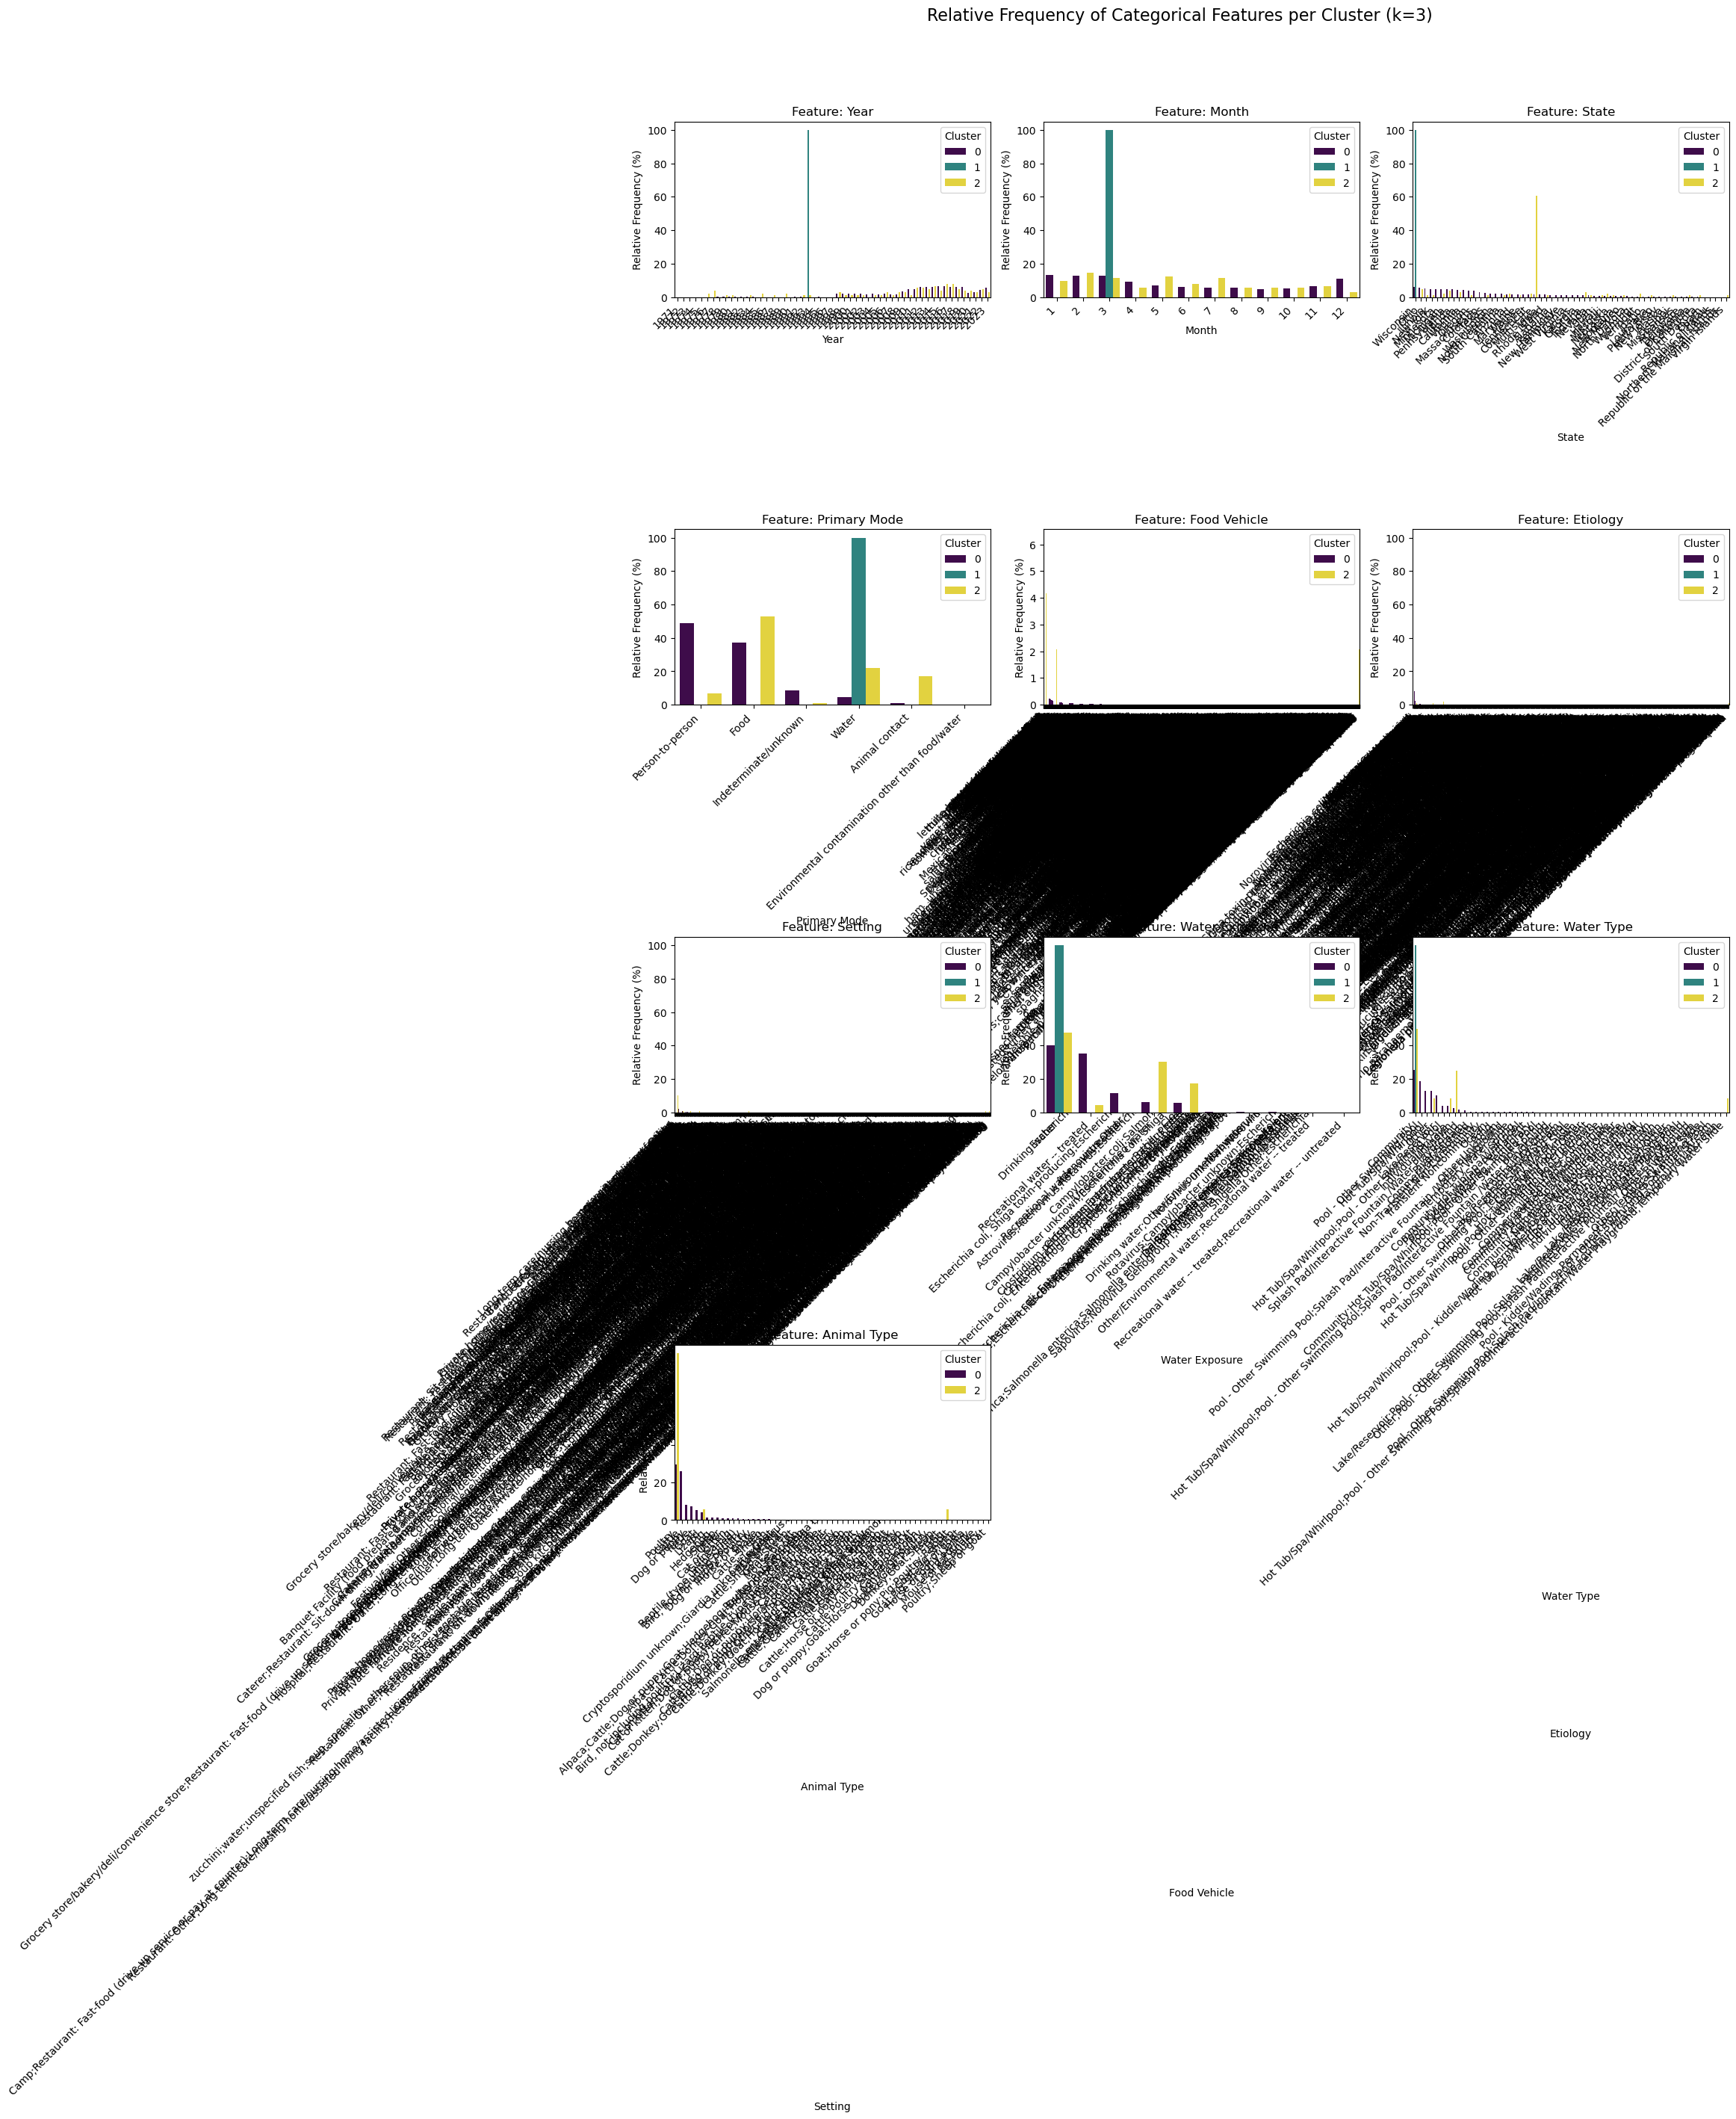

Generating plots for k=4...


C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rec

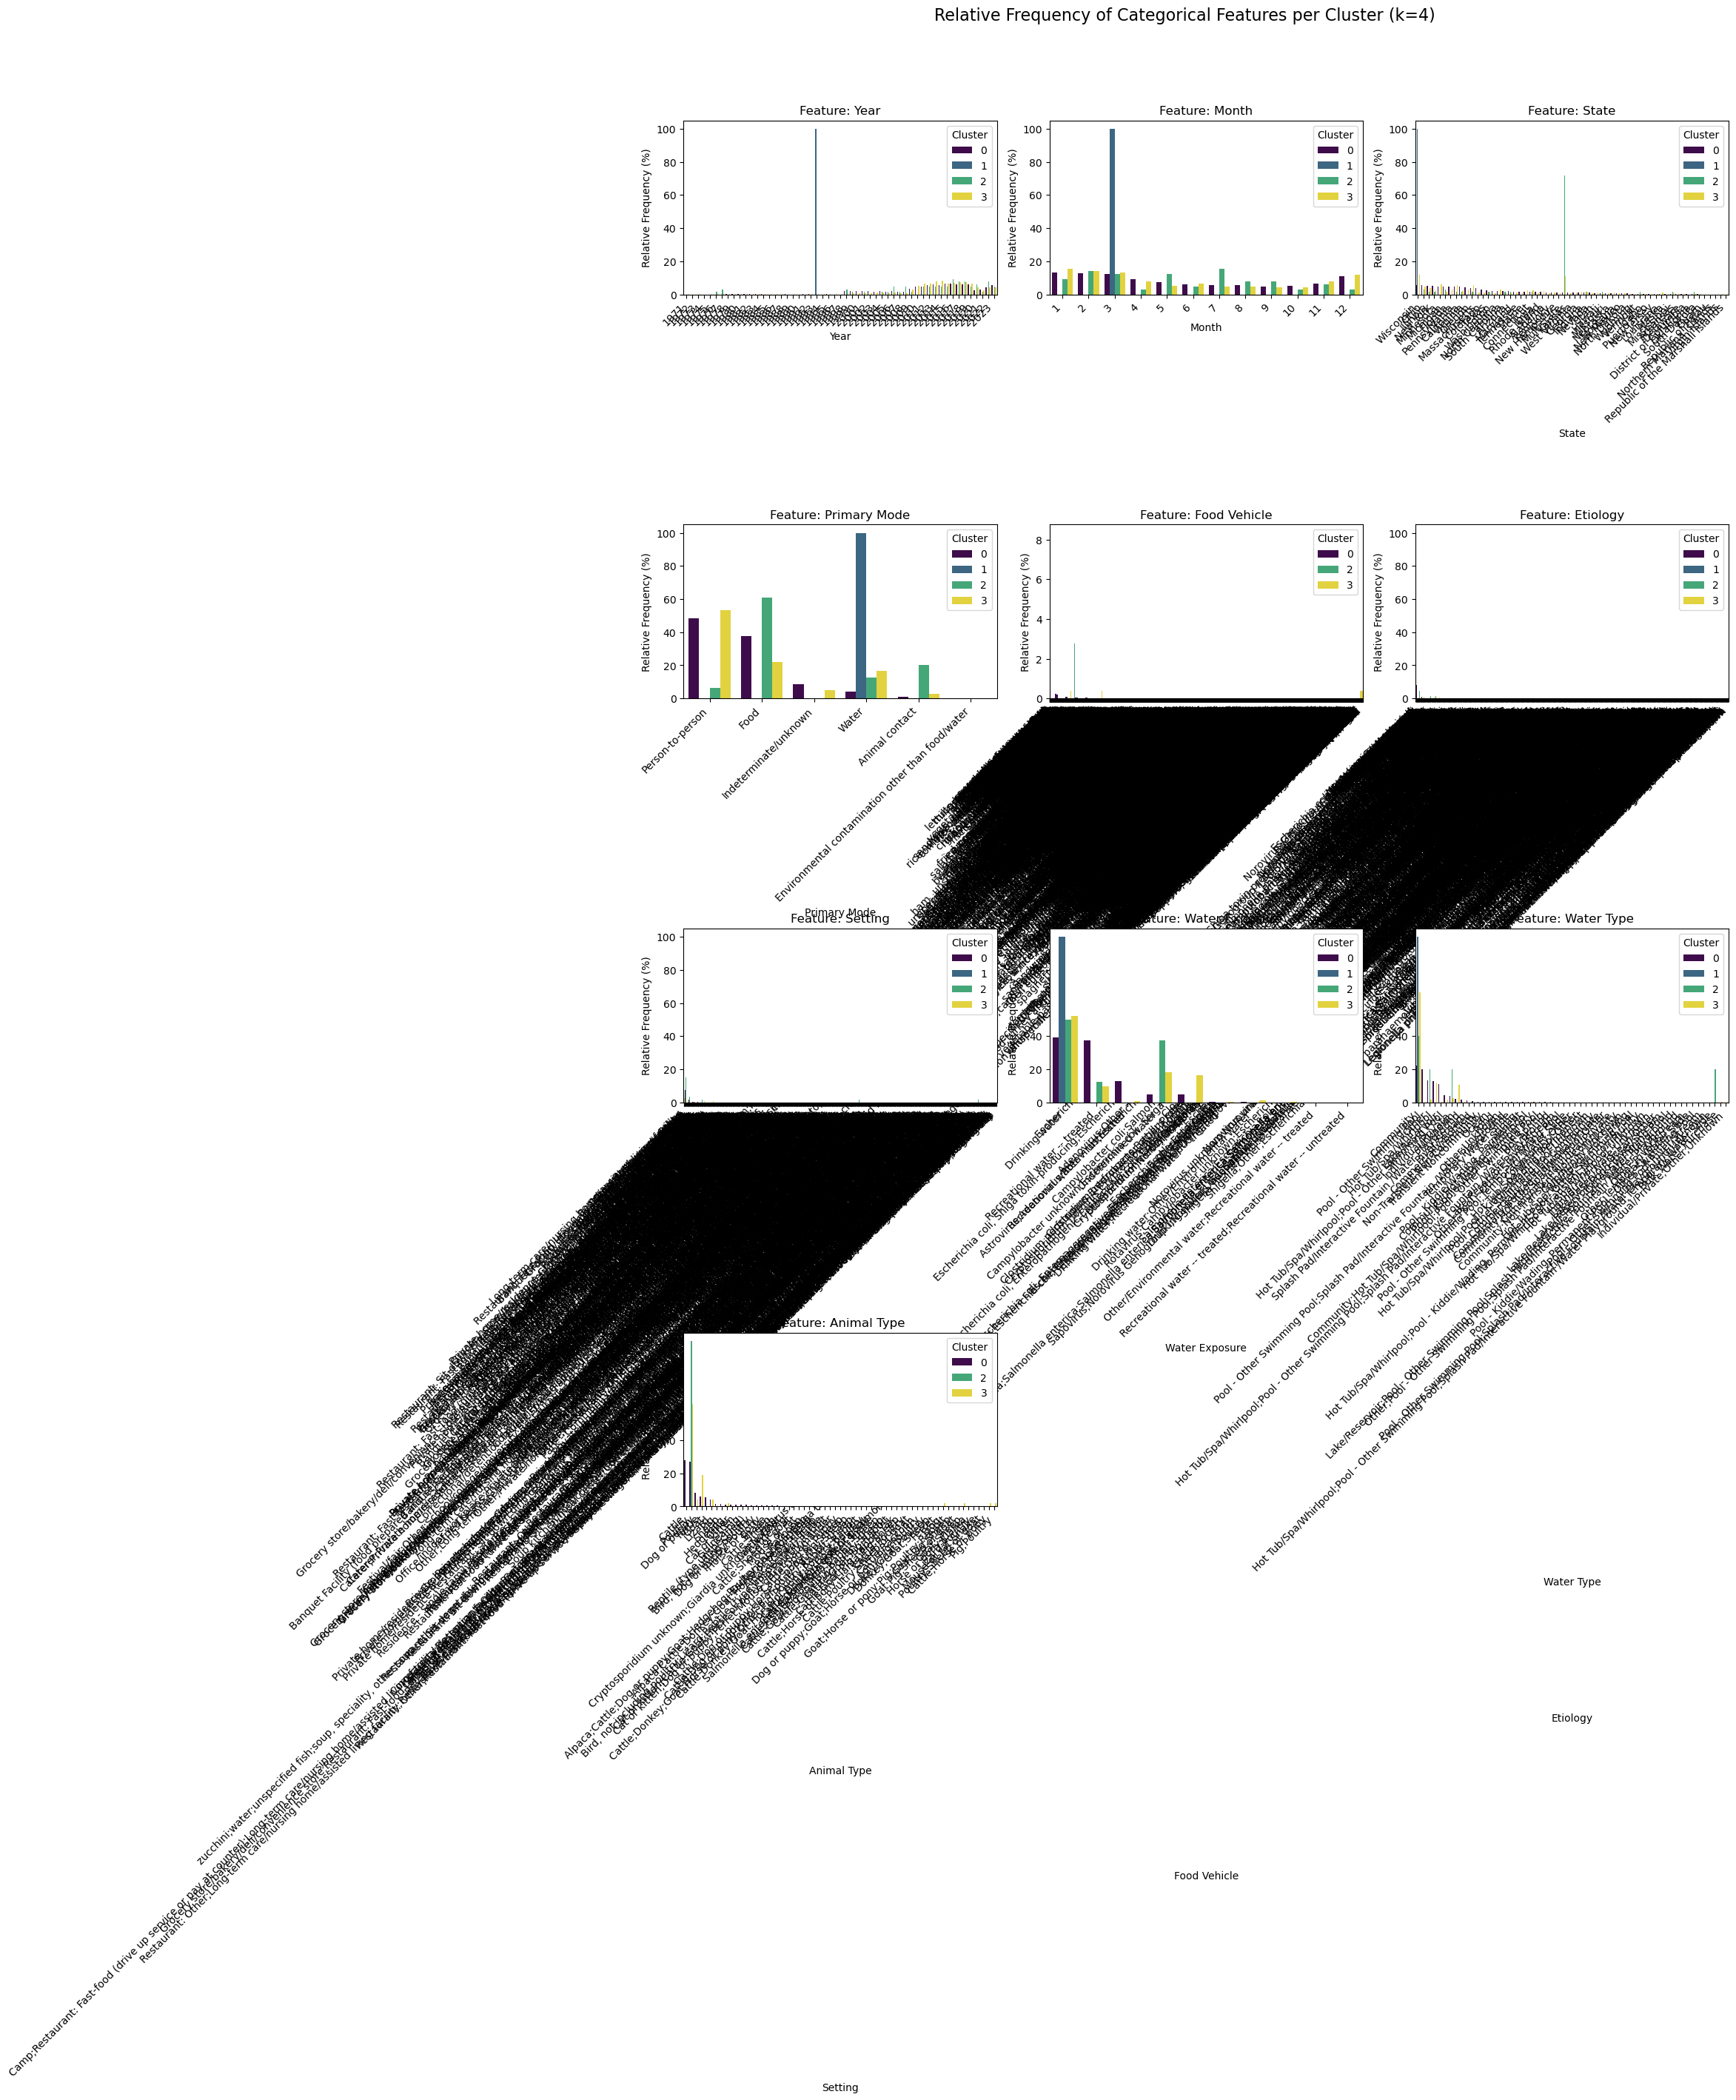

Generating plots for k=5...


C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
C:\Users\jared\AppData\Local\Temp\ipykernel_87360\3096430184.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rec

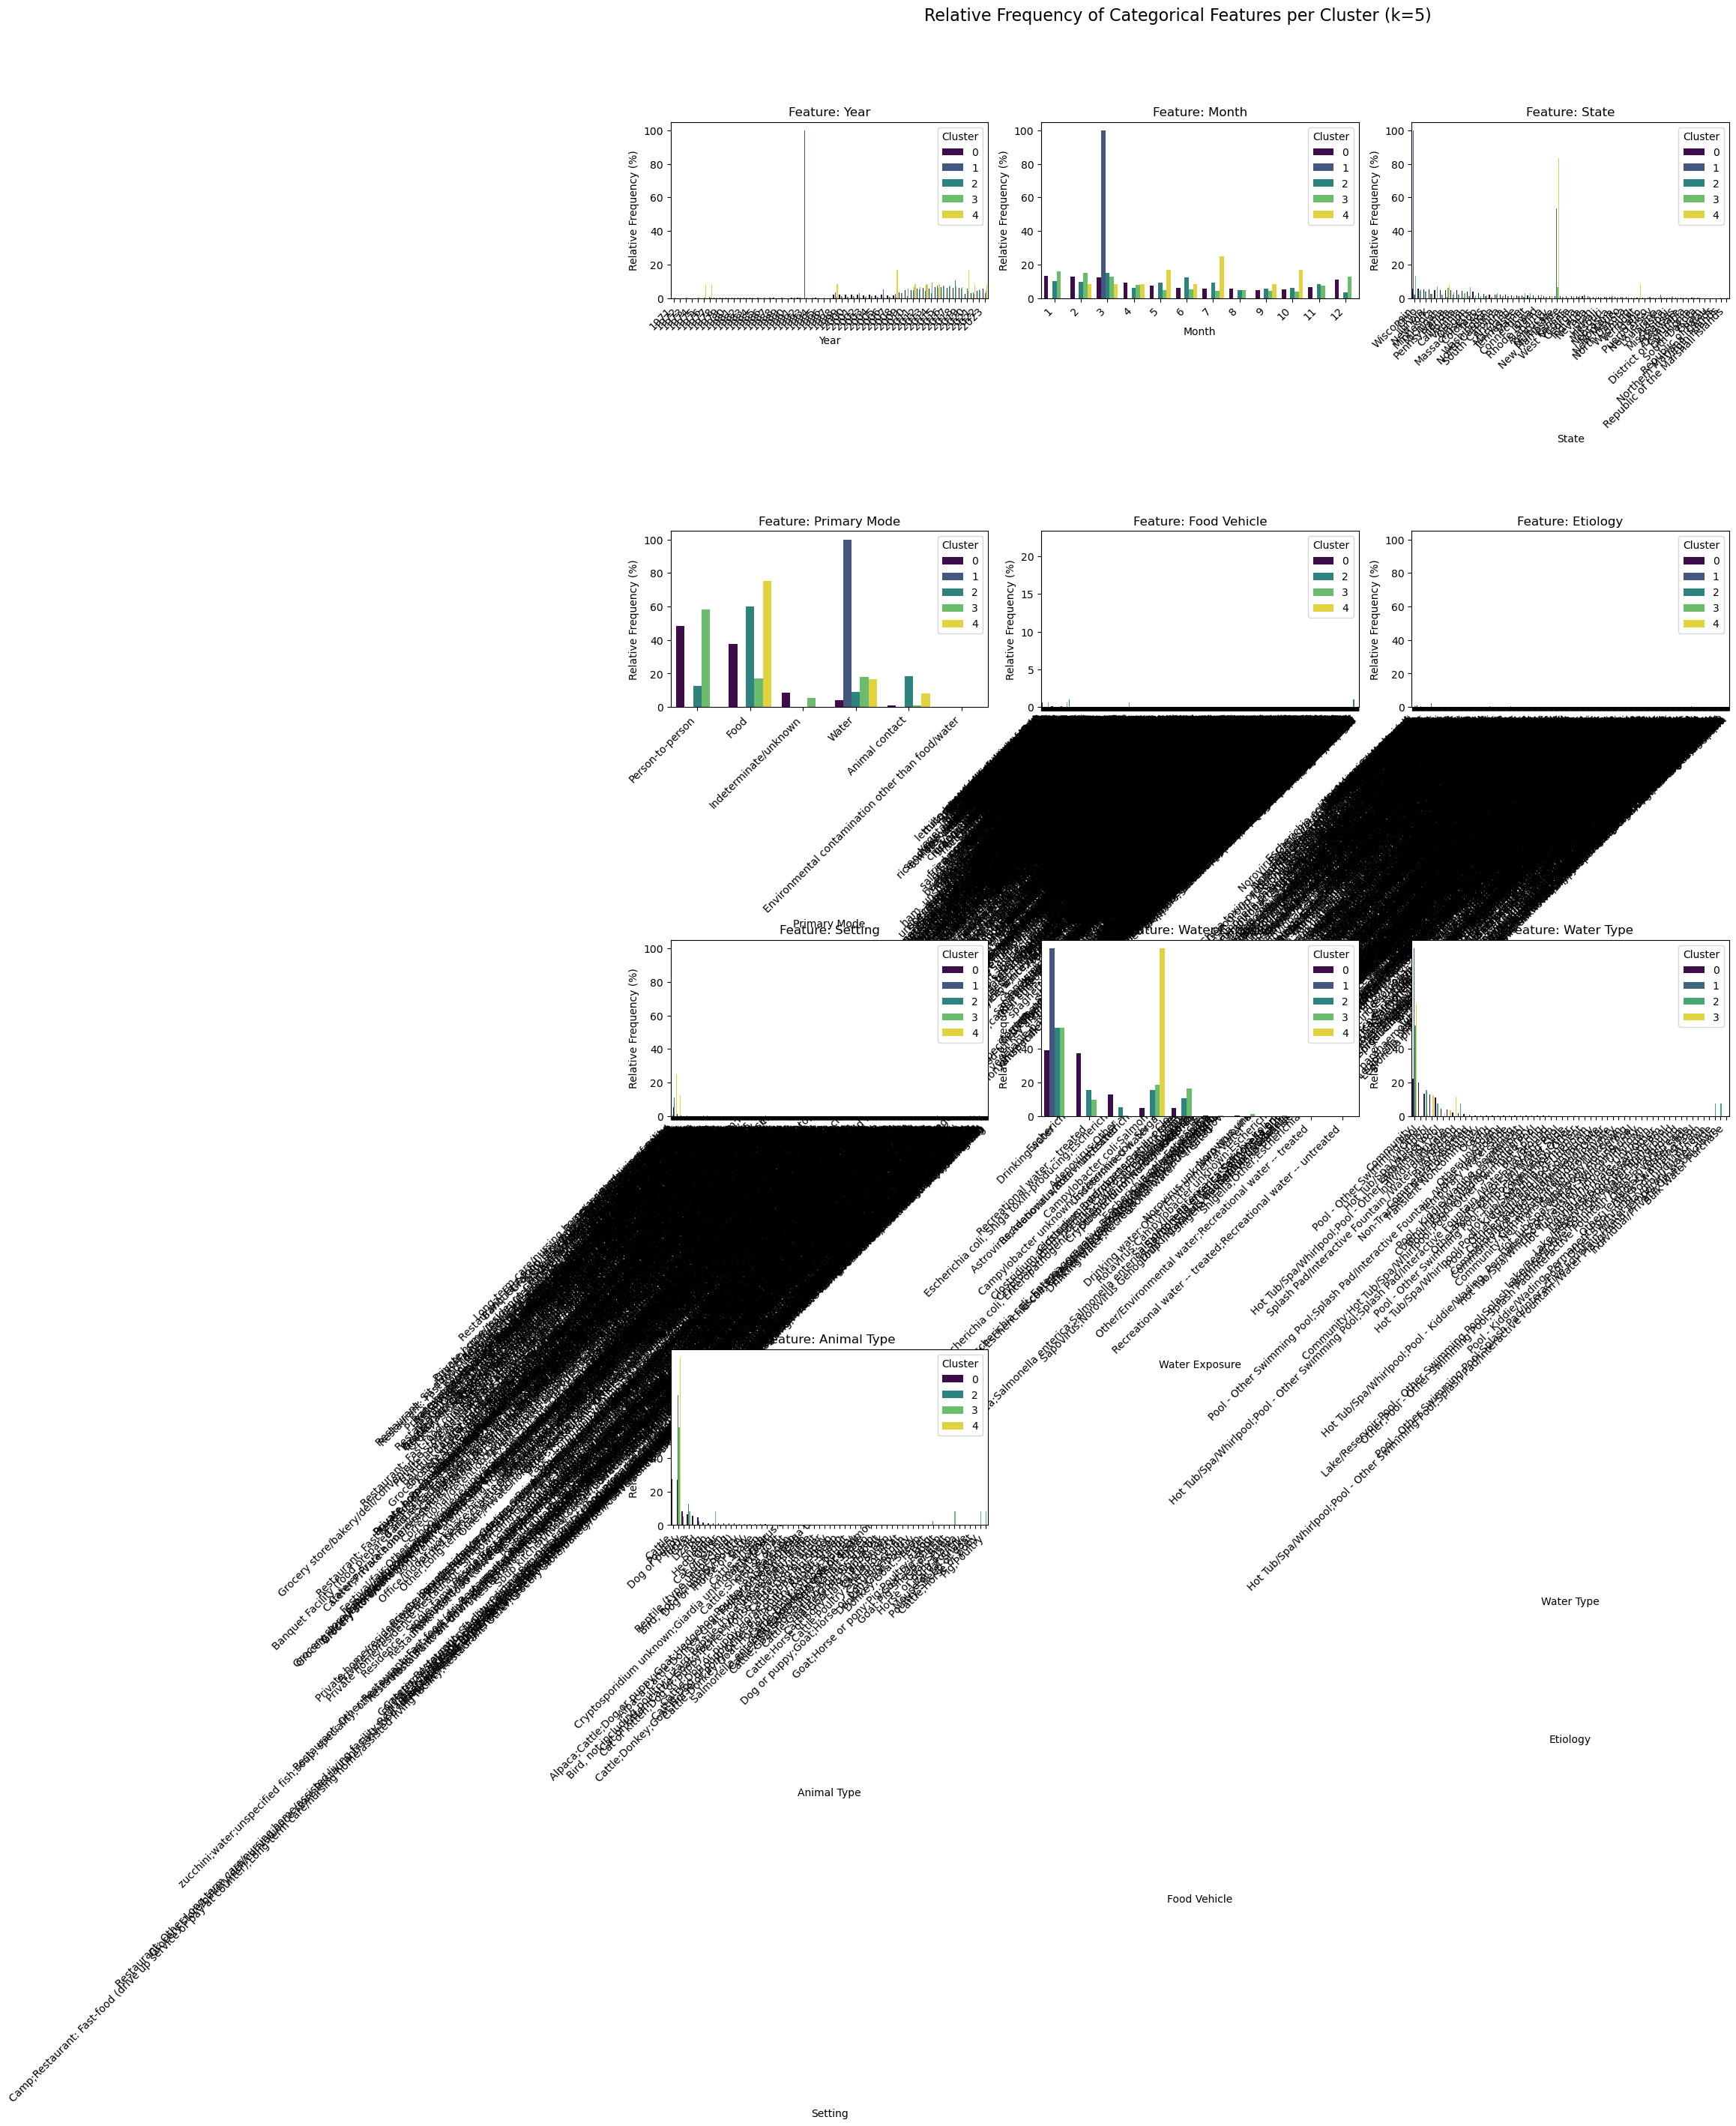

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Define the Function ---
def plot_cluster_relative_frequencies(df, cluster_column_name, categorical_features):
    """
    Generates bar plots showing the relative frequency of categorical features
    within each cluster.

    Args:
        df (pd.DataFrame): The DataFrame containing features and cluster labels.
        cluster_column_name (str): The name of the cluster column (e.g., 'Cluster_k4').
        categorical_features (list): A list of categorical column names to plot.
    """
    num_clusters = df[cluster_column_name].nunique()
    
    # Calculate the number of rows and columns for the subplot grid
    n_features = len(categorical_features)
    n_cols = 3 
    n_rows = (n_features + n_cols - 1) // n_cols # Ceiling division

    plt.figure(figsize=(n_cols * 5, n_rows * 5))
    plt.suptitle(f'Relative Frequency of Categorical Features per Cluster (k={num_clusters})', 
                 fontsize=16, y=1.02)
    
    # Iterate through each categorical feature
    for i, feature in enumerate(categorical_features):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Calculate the relative frequency (proportions)
        # 1. Group by Cluster and Feature
        # 2. Count the occurrences (size())
        # 3. Divide by the total count within each Cluster (level=0)
        proportions = df.groupby(cluster_column_name)[feature].value_counts(normalize=True).mul(100).rename('Percent').reset_index()

        # Plot the result
        sns.barplot(
            x=feature, 
            y='Percent', 
            hue=cluster_column_name, 
            data=proportions,
            palette='viridis'
        )
        
        plt.title(f'Feature: {feature}')
        plt.ylabel('Relative Frequency (%)')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Cluster')
        plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle

    plt.show()

# --- 2. Define Inputs ---
# These are the categorical columns you requested
categorical_features = [
    'Year', 'Month', 'State', 'Primary Mode', 'Food Vehicle', 
    'Etiology', 'Setting', 'Water Exposure', 'Water Type', 'Animal Type'
]

# --- 3. Execute the Plots for k=3, k=4, and k=5 ---

# NOTE: The cluster columns are created in the previous code cell,
# so we assume 'Cluster_k3', 'Cluster_k4', and 'Cluster_k5' exist in df.

print("Generating plots for k=3...")
plot_cluster_relative_frequencies(df, 'Cluster_k3', categorical_features)

print("Generating plots for k=4...")
plot_cluster_relative_frequencies(df, 'Cluster_k4', categorical_features)

print("Generating plots for k=5...")
plot_cluster_relative_frequencies(df, 'Cluster_k5', categorical_features)